In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

# <center>Loading data </center>

In [3]:
df_date=pd.read_csv("dim_date.csv")

In [4]:
df_date

,date,fiscal_year,quarter
0,01-Apr-21,2022,Q1
1,01-May-21,2022,Q1
2,01-Jun-21,2022,Q1
3,01-Jul-21,2022,Q2
4,01-Aug-21,2022,Q2
5,01-Sep-21,2022,Q2
6,01-Oct-21,2022,Q3
7,01-Nov-21,2022,Q3
8,01-Dec-21,2022,Q3
9,01-Jan-22,2022,Q4


In [5]:
df_makers_sales=pd.read_csv("electric_vehicle_sales_by_makers.csv")

In [6]:
df_makers_sales

,date,vehicle_category,maker,electric_vehicles_sold
0,01-Apr-21,2-Wheelers,OLA ELECTRIC,0
1,01-Apr-22,2-Wheelers,OKAYA EV,0
2,01-May-21,2-Wheelers,OLA ELECTRIC,0
3,01-Jun-21,2-Wheelers,OLA ELECTRIC,0
4,01-Jul-21,2-Wheelers,OLA ELECTRIC,0
...,...,...,...,...
811,01-Mar-24,2-Wheelers,BGAUSS,3070
812,01-Mar-24,2-Wheelers,BATTRE ELECTRIC,625
813,01-Mar-24,2-Wheelers,KINETIC GREEN,3915
814,01-Mar-24,2-Wheelers,REVOLT,585


In [7]:
df_state_sales=pd.read_csv("electric_vehicle_sales_by_state.csv")

In [8]:
df_state_sales

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold
0,01-Apr-21,Sikkim,2-Wheelers,0,398
1,01-Apr-21,Sikkim,4-Wheelers,0,361
2,01-May-21,Sikkim,2-Wheelers,0,113
3,01-May-21,Sikkim,4-Wheelers,0,98
4,01-Jun-21,Sikkim,2-Wheelers,0,229
...,...,...,...,...,...
2440,01-Mar-24,Mizoram,2-Wheelers,58,1932
2441,01-Mar-24,DNH and DD,2-Wheelers,25,780
2442,01-Mar-24,Manipur,2-Wheelers,13,1394
2443,01-Mar-24,Andaman & Nicobar Island,2-Wheelers,2,447


# <center> Cleaning and Preparing Data </center>

In [10]:
df_date.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         36 non-null     object
 1   fiscal_year  36 non-null     int64 
 2   quarter      36 non-null     object
dtypes: int64(1), object(2)
memory usage: 996.0+ bytes


In [11]:
df_date.dtypes

date           object
fiscal_year     int64
quarter        object
dtype: object

In [12]:
#fixing date column
df_date["date"]=pd.to_datetime(df_date["date"])
df_date

,date,fiscal_year,quarter
0,2021-04-01,2022,Q1
1,2021-05-01,2022,Q1
2,2021-06-01,2022,Q1
3,2021-07-01,2022,Q2
4,2021-08-01,2022,Q2
5,2021-09-01,2022,Q2
6,2021-10-01,2022,Q3
7,2021-11-01,2022,Q3
8,2021-12-01,2022,Q3
9,2022-01-01,2022,Q4


In [13]:
df_date.dtypes

date           datetime64[ns]
fiscal_year             int64
quarter                object
dtype: object

In [14]:
#fixing date column before merging , bcz both date col should be of same datatype
df_makers_sales["date"]=pd.to_datetime(df_makers_sales["date"])

In [15]:
df_maker_sales=pd.merge(df_makers_sales,df_date,on="date",how="left")

In [16]:
print(df_maker_sales.columns)
df_maker_sales

Index(['date', 'vehicle_category', 'maker', 'electric_vehicles_sold',
       'fiscal_year', 'quarter'],
      dtype='object')


,date,vehicle_category,maker,electric_vehicles_sold,fiscal_year,quarter
0,2021-04-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
1,2022-04-01,2-Wheelers,OKAYA EV,0,2023,Q1
2,2021-05-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
3,2021-06-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
4,2021-07-01,2-Wheelers,OLA ELECTRIC,0,2022,Q2
...,...,...,...,...,...,...
811,2024-03-01,2-Wheelers,BGAUSS,3070,2024,Q4
812,2024-03-01,2-Wheelers,BATTRE ELECTRIC,625,2024,Q4
813,2024-03-01,2-Wheelers,KINETIC GREEN,3915,2024,Q4
814,2024-03-01,2-Wheelers,REVOLT,585,2024,Q4


In [17]:
df_maker_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    816 non-null    datetime64[ns]
 1   vehicle_category        816 non-null    object        
 2   maker                   816 non-null    object        
 3   electric_vehicles_sold  816 non-null    int64         
 4   fiscal_year             816 non-null    int64         
 5   quarter                 816 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 38.4+ KB


In [18]:
df_maker_sales.describe()

,date,electric_vehicles_sold,fiscal_year
count,816,816.000000,816.000000
mean,2022-09-21 03:30:00,2531.998775,2023.014706
min,2021-04-01 00:00:00,0.000000,2022.000000
25%,2022-01-01 00:00:00,42.000000,2022.000000
50%,2022-10-01 00:00:00,662.000000,2023.000000
75%,2023-07-01 00:00:00,2636.500000,2024.000000
max,2024-03-01 00:00:00,44630.000000,2024.000000
std,NaN,4771.077333,0.813855


In [19]:
#converting date column datatype before merging . bcz both date col should be of same data type.
df_state_sales['date']=pd.to_datetime(df_state_sales['date'])

In [20]:
df_state_sales=pd.merge(df_state_sales,df_date,on=['date'], how='left')
#also written as ,  df_state_sales.merge(df_date,on=['date'])

In [21]:
#there were 2 distinct names denoting the same state in the df.
#to replace a value
df_state_sales['state'] = df_state_sales['state'].replace('Andaman & Nicobar','Andaman & Nicobar Island')
#df_state_sales.loc[df_state_sales['state']=='Andaman & Nicobar','state']='Andaman & Nicobar Island'

In [22]:
df_state_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    2445 non-null   datetime64[ns]
 1   state                   2445 non-null   object        
 2   vehicle_category        2445 non-null   object        
 3   electric_vehicles_sold  2445 non-null   int64         
 4   total_vehicles_sold     2445 non-null   int64         
 5   fiscal_year             2445 non-null   int64         
 6   quarter                 2445 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 133.8+ KB


In [23]:
df_state_sales.describe()

,date,electric_vehicles_sold,total_vehicles_sold,fiscal_year
count,2445,2445.000000,2445.000000,2445.000000
mean,2022-09-15 12:50:56.687116544,845.035174,23402.966053,2022.999591
min,2021-04-01 00:00:00,0.000000,1.000000,2022.000000
25%,2022-01-01 00:00:00,2.000000,1158.000000,2022.000000
50%,2022-09-01 00:00:00,54.000000,6098.000000,2023.000000
75%,2023-06-01 00:00:00,534.000000,29396.000000,2024.000000
max,2024-03-01 00:00:00,26668.000000,387983.000000,2024.000000
std,NaN,2185.167744,38353.266389,0.816413


# <center>Exploratory Data Analysis and Visualization </center>

## 1.List the top 3 and bottom 3 makers for the fiscal years 2023 and 2024 in terms of the number of 2-wheelers sold


In [26]:
result=df_maker_sales.groupby(["maker","fiscal_year"]).agg({'electric_vehicles_sold':'sum'}).reset_index()


top_2023=result[result['fiscal_year']==2023].sort_values(by='electric_vehicles_sold',ascending=False).head(3)
bottom_2023=result[result['fiscal_year']==2023].sort_values(by='electric_vehicles_sold',ascending=False).tail(3)
top_2024=result[result['fiscal_year']==2024].sort_values(by='electric_vehicles_sold',ascending=False).head(3)
bottom_2024=result[result['fiscal_year']==2023].sort_values(by='electric_vehicles_sold',ascending=False).tail(3)

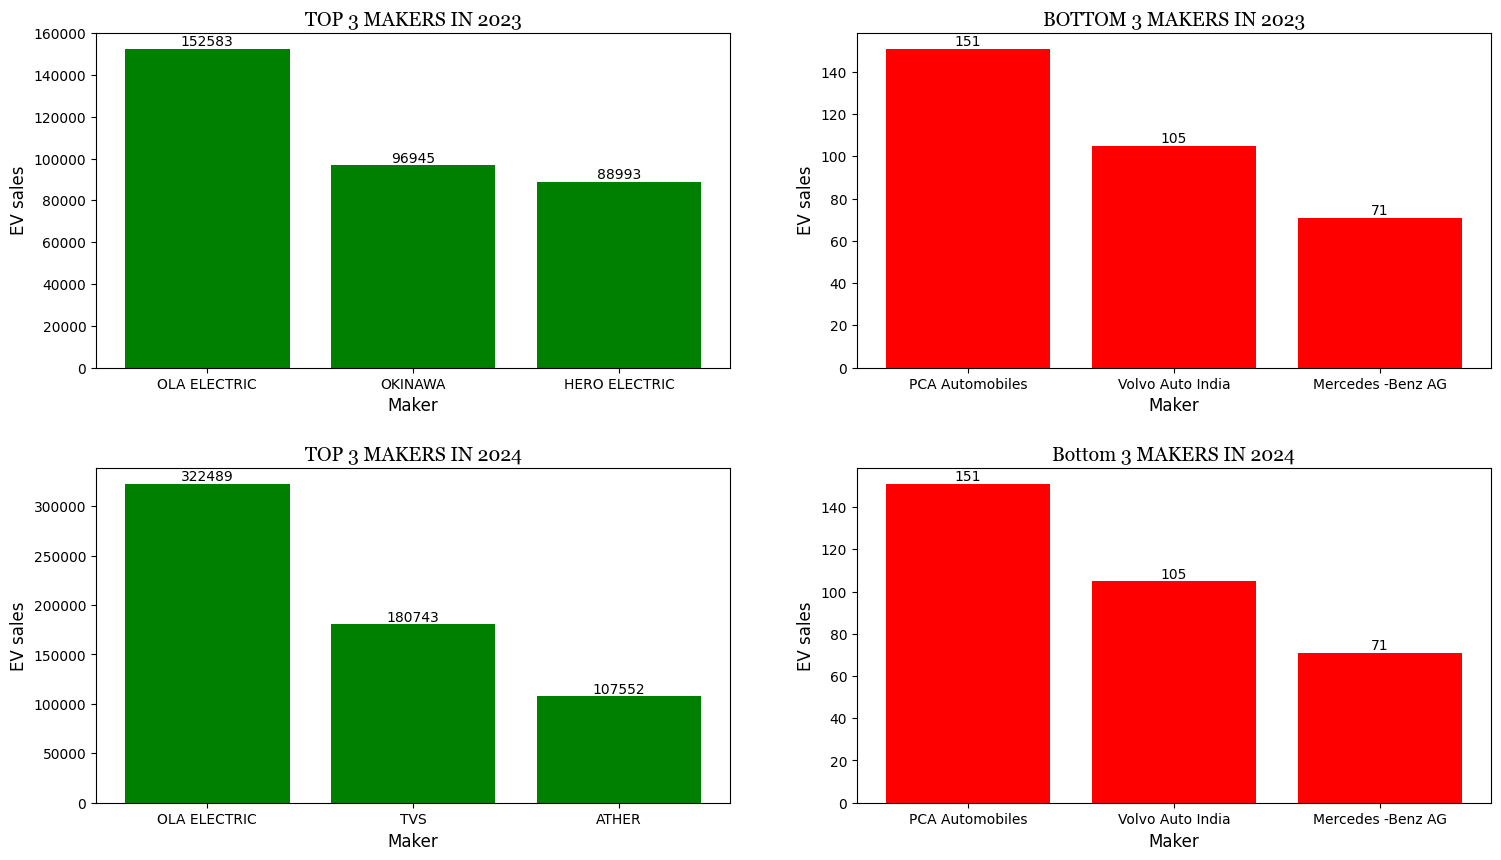

In [27]:
fig,axes = plt.subplots(2 , 2 , figsize=(18,10))
plt.subplots_adjust(wspace=0.2, hspace=0.3) #wspace for width hspace for height

def add_bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container,label_type='edge')
#plotting top 3 makers 
axes[0,0].bar(top_2023['maker'],top_2023['electric_vehicles_sold'],color='green')
axes[0,0].set_title("TOP 3 MAKERS IN 2023",font='Georgia',fontsize=14)
axes[0,0].set_xlabel('Maker',fontsize=12)
axes[0,0].set_ylabel('EV sales',fontsize=12)
add_bar_labels(axes[0,0])
#plotting bottom 3 in 2023
axes[0,1].bar(bottom_2023['maker'],bottom_2023['electric_vehicles_sold'],color='red')
axes[0,1].set_title("BOTTOM 3 MAKERS IN 2023",font='Georgia',fontsize=14)
axes[0,1].set_xlabel('Maker',fontsize=12)
axes[0,1].set_ylabel('EV sales',fontsize=12)
add_bar_labels(axes[0,1])
#plotting top 3 in 2024
axes[1,0].bar(top_2024['maker'],top_2024['electric_vehicles_sold'],color='green')
axes[1,0].set_title("TOP 3 MAKERS IN 2024",font='Georgia',fontsize=14)
axes[1,0].set_xlabel('Maker',fontsize=12)
axes[1,0].set_ylabel('EV sales',fontsize=12)
add_bar_labels(axes[1,0])
#plotting bottom 3 in 2024
axes[1,1].bar(bottom_2024['maker'],bottom_2024['electric_vehicles_sold'],color='red')
axes[1,1].set_title("Bottom 3 MAKERS IN 2024",font='Georgia',fontsize=14)
axes[1,1].set_xlabel('Maker',fontsize=12)
axes[1,1].set_ylabel('EV sales',fontsize=12)
add_bar_labels(axes[1,1])



## 2.Identify the top 5 states with the highest penetration rate in 2-wheeler and 4-wheeler EV sales in FY 2024.

In [114]:
result1=df_state_sales.groupby(['state','fiscal_year','vehicle_category']).agg(
             electric_vehicles_sold=('electric_vehicles_sold','sum'),total_vehicles_sold=('total_vehicles_sold','sum')
                                                                              ).reset_index()
#using the reset_index() method moves the grouped columns (state, fiscal_year, vehicle_category) from the index back to regular columns.
#helpful for further analysis and filtering on the grouped df . keeps the process error-free

In [31]:
result1.dtypes

state                     object
fiscal_year                int64
vehicle_category          object
electric_vehicles_sold     int64
total_vehicles_sold        int64
dtype: object

In [32]:
# Convert the columns to numeric types , bcz the columns were  showing as object type(means string)  before .which is not a numeric(float/int) .
#this gave error while finding penetration rate 
result1['electric_vehicles_sold'] = pd.to_numeric(result1['electric_vehicles_sold'], errors='coerce')
result1['total_vehicles_sold'] = pd.to_numeric(result1['total_vehicles_sold'], errors='coerce')


In [33]:
result1['Penetration rate']= result1['electric_vehicles_sold']/result1['total_vehicles_sold']*100

In [34]:
result1

,state,fiscal_year,vehicle_category,electric_vehicles_sold,total_vehicles_sold,Penetration rate
0,Andaman & Nicobar Island,2022,2-Wheelers,0,3979,0.000000
1,Andaman & Nicobar Island,2022,4-Wheelers,22,1169,1.881950
2,Andaman & Nicobar Island,2023,2-Wheelers,17,4758,0.357293
3,Andaman & Nicobar Island,2023,4-Wheelers,6,1776,0.337838
4,Andaman & Nicobar Island,2024,2-Wheelers,20,5249,0.381025
...,...,...,...,...,...,...
199,West Bengal,2022,4-Wheelers,418,93782,0.445715
200,West Bengal,2023,2-Wheelers,9580,808092,1.185509
201,West Bengal,2023,4-Wheelers,1431,105466,1.356835
202,West Bengal,2024,2-Wheelers,14016,855595,1.638158


In [35]:
PR_2024_2w=result1[(result1['fiscal_year']==2024) & (result1['vehicle_category']=='2-Wheelers')].sort_values(by='Penetration rate',ascending=False).head(5)

In [36]:
PR_2024_4w=result1[(result1['fiscal_year']==2024) & (result1['vehicle_category']=='4-Wheelers')].sort_values(by='Penetration rate',ascending=False).head(5)

In [132]:
print("TOP 5 states with PR IN 2-wheelers")
print(PR_2024_2w)
print()
print("TOP 5 states with PR IN 4-wheelers")
print(PR_2024_4w)

TOP 5 states with PR IN 2-wheelers
           state  fiscal_year vehicle_category  electric_vehicles_sold  \
58           Goa         2024       2-Wheelers                    9768   
100       Kerala         2024       2-Wheelers                   64769   
94     Karnataka         2024       2-Wheelers                  148111   
118  Maharashtra         2024       2-Wheelers                  183052   
52         Delhi         2024       2-Wheelers                   38094   

     total_vehicles_sold  Penetration rate  
58                 54290         17.992264  
100               478887         13.524903  
94               1279767         11.573279  
118              1817343         10.072507  
52                405218          9.400866  

TOP 5 states with PR IN 4-wheelers
          state  fiscal_year vehicle_category  electric_vehicles_sold  \
101      Kerala         2024       4-Wheelers                    9169   
35   Chandigarh         2024       4-Wheelers                    102

In [38]:
#to cheeck unique values 
print(result1['fiscal_year'].unique())

[2022 2023 2024]


In [39]:
print(result1['vehicle_category'].unique())

['2-Wheelers' '4-Wheelers']


In [40]:
#to remove trailing spaces
result1['vehicle_category'] = result1['vehicle_category'].str.strip()

In [41]:
#to find null values in a column 
print(result1[['fiscal_year', 'vehicle_category']].isnull().sum())

fiscal_year         0
vehicle_category    0
dtype: int64


In [42]:
PR_2024_2w.state

58             Goa
100         Kerala
94       Karnataka
118    Maharashtra
52           Delhi
Name: state, dtype: object

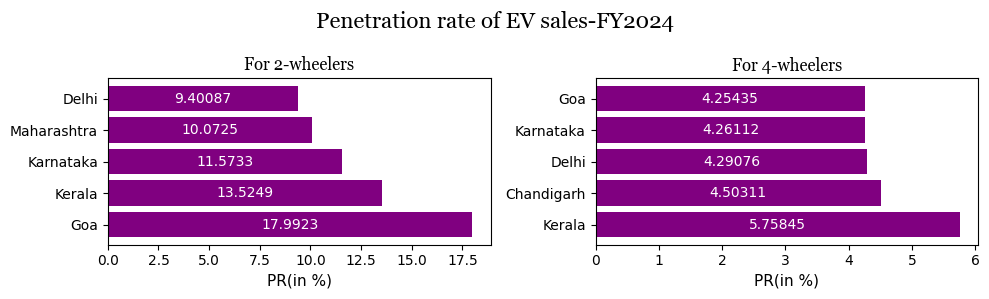

In [43]:
fig,axes=plt.subplots(1,2,figsize=(10,3))
fig.suptitle('Penetration rate of EV sales-FY2024',font='Georgia',fontsize=16)
def bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container,label_type='center',color='white',fontsize=10)
#bcz only 2 set of axes are arranged in one row , which means axes is 1D array , so in []bracket we can only give row value or column val ,such as, 
axes[0].barh(PR_2024_2w['state'],PR_2024_2w['Penetration rate'],color='purple')
axes[0].set_title('For 2-wheelers',font='Georgia',fontsize=12)
#If the title is long and you want it to wrap across two lines, use \n to insert a line break
axes[0].set_xlabel('PR(in %)',fontsize=11)
bar_labels(axes[0])

axes[1].barh(PR_2024_4w['state'],PR_2024_4w['Penetration rate'],color='purple')
axes[1].set_title('For 4-wheelers',font='Georgia',fontsize=12)
axes[1].set_xlabel('PR(in %)',fontsize=11) 
bar_labels(axes[1])


plt.tight_layout()  # Adjusts spacing to prevent clipping
plt.show()

## 3. List the states with negative penetration (decline) in EV sales from 2022 to 2024

In [45]:
# df_state_sales is already grouped and filtered as 'result1'
#will use the same result without using reset_index()
#when year or category filter is needed
#df_filtered=df_state_sales[df_state_sales['fiscal_year'].isin([2022,2023,2024])]
#df_filtered=df_filtered[df_filtered['vehicle_category'].isin(['2-Wheelers','4-Wheelers'])]

df_grouped=df_state_sales.groupby(['state','fiscal_year']).agg({'electric_vehicles_sold':sum,'total_vehicles_sold':sum}).reset_index()
df_grouped['Penetration rate']=(df_grouped['electric_vehicles_sold']/df_grouped['total_vehicles_sold']*100)
print(df_grouped.columns)
result3=df_grouped.pivot(columns='fiscal_year',index='state',values='Penetration rate')
result3['decline_2022vs2023']=(result3[2023]-result3[2022])
result3['decline_2023vs2024']=(result3[2024]-result3[2023])
result3[(result3['decline_2022vs2023']<0) | (result3['decline_2023vs2024']<0)]

Index(['state', 'fiscal_year', 'electric_vehicles_sold', 'total_vehicles_sold',
       'Penetration rate'],
      dtype='object')


fiscal_year,2022,2023,2024,decline_2022vs2023,decline_2023vs2024
state,,,,,
Andaman & Nicobar Island,0.427350,0.352005,0.485909,-0.075346,0.133904
Gujarat,1.646403,5.487563,5.302306,3.841160,-0.185257
Haryana,1.121094,2.036602,1.611002,0.915509,-0.425600
Himachal Pradesh,0.450817,1.003490,0.895084,0.552673,-0.108407
Jharkhand,0.659114,1.727833,1.581783,1.068718,-0.146050
Rajasthan,2.280062,5.668529,5.109206,3.388467,-0.559322
Uttarakhand,1.199439,3.103600,2.718018,1.904161,-0.385581


# Penetration rates of EV for 2-wheelers & 4-wheelers from 2022 to 2024

In [46]:
#if we want to convert result1 df into pivot 
result1.pivot(columns=['fiscal_year','vehicle_category'],index='state',values='Penetration rate')

fiscal_year                    2022                  2023             \
vehicle_category         2-Wheelers 4-Wheelers 2-Wheelers 4-Wheelers   
state                                                                  
Andaman & Nicobar Island   0.000000   1.881950   0.357293   0.337838   
Andhra Pradesh             1.963438   0.532423   4.582675   1.153312   
Arunachal Pradesh          0.000000   0.000000   0.007849   0.009103   
Assam                      0.231152   0.016082   0.533918   0.131623   
Bihar                      0.573707   0.121681   1.146267   0.303348   
Chandigarh                 1.761301   0.603398   7.101899   1.761403   
Chhattisgarh               1.285527   0.255804   5.220012   0.981215   
DNH and DD                 0.345304   0.134228   1.033958   0.423819   
Delhi                      5.356224   1.682367   9.523637   3.727794   
Goa                        4.181760   2.416156  12.465068   3.174603   
Gujarat                    2.016538   0.479142   6.792754   1.017865   
Haryana                    1.641115   0.070290   2.794813   0.677192   
Himachal Pradesh           0.739759   0.046398   1.589536   0.145573   
Jammu and Kashmir          1.778279   0.029519   2.531909   0.120363   
Jharkhand                  0.739129   0.109047   1.892750   0.496851   
Karnataka                  5.136367   0.897421   9.188389   2.095945   
Kerala                     2.318056   1.130750   8.416882   2.420060   
Ladakh                     4.477612   0.000000   0.732780   0.428816   
Madhya Pradesh             0.911184   0.194891   2.513729   0.483004   
Maharashtra                3.193924   1.822601   8.203266   2.608063   
Manipur                    0.087458   0.000000   0.350594   0.087252   
Meghalaya                  0.000000   0.043225   0.161057   0.082360   
Mizoram                    0.000000   0.000000   0.328018   0.000000   
Nagaland                   0.018129   0.000000   0.050934   0.000000   
Odisha                     2.216054   0.246116   5.598805   0.756340   
Puducherry                 2.040240   0.146510   4.061824   0.538827   
Punjab                     1.327165   0.044510   2.011218   0.045242   
Rajasthan                  2.628778   0.527925   6.575819   1.096214   
Sikkim                     0.000000   0.000000   0.000000   0.000000   
Tamil Nadu                 3.104235   0.605980   4.876354   1.288127   
Tripura                    0.083358   0.000000   0.608212   0.191571   
Uttar Pradesh              0.462938   0.038079   1.143831   0.178846   
Uttarakhand                1.442918   0.433097   3.806068   0.790121   
West Bengal                0.295595   0.445715   1.185509   1.356835   

fiscal_year                    2024             
vehicle_category         2-Wheelers 4-Wheelers  
state                                           
Andaman & Nicobar Island   0.381025   0.767656  
Andhra Pradesh             4.517040   2.061740  
Arunachal Pradesh          0.020446   0.211816  
Assam                      0.693633   0.361936  
Bihar                      1.358305   0.936572  
Chandigarh                 8.254801   4.503112  
Chhattisgarh               6.048292   2.418145  
DNH and DD                 1.367851   0.889777  
Delhi                      9.400866   4.290757  
Goa                       17.992264   4.254353  
Gujarat                    6.236805   2.045695  
Haryana                    1.951699   1.025607  
Himachal Pradesh           1.305633   0.326058  
Jammu and Kashmir          2.511239   0.301500  
Jharkhand                  1.680246   0.805670  
Karnataka                 11.573279   4.261120  
Kerala                    13.524903   5.758445  
Ladakh                     4.062910   0.000000  
Madhya Pradesh             3.703720   0.962178  
Maharashtra               10.072507   2.961706  
Manipur                    0.620592   0.895804  
Meghalaya                  0.471488   0.190867  
Mizoram                    1.243476   0.018563  
Nagaland                   0.066525   0.042301  
Odisha      

## 4. What are the quarterly trends based on sales volume for the top 5 EV makers (4-wheelers) from 2022 to 2024

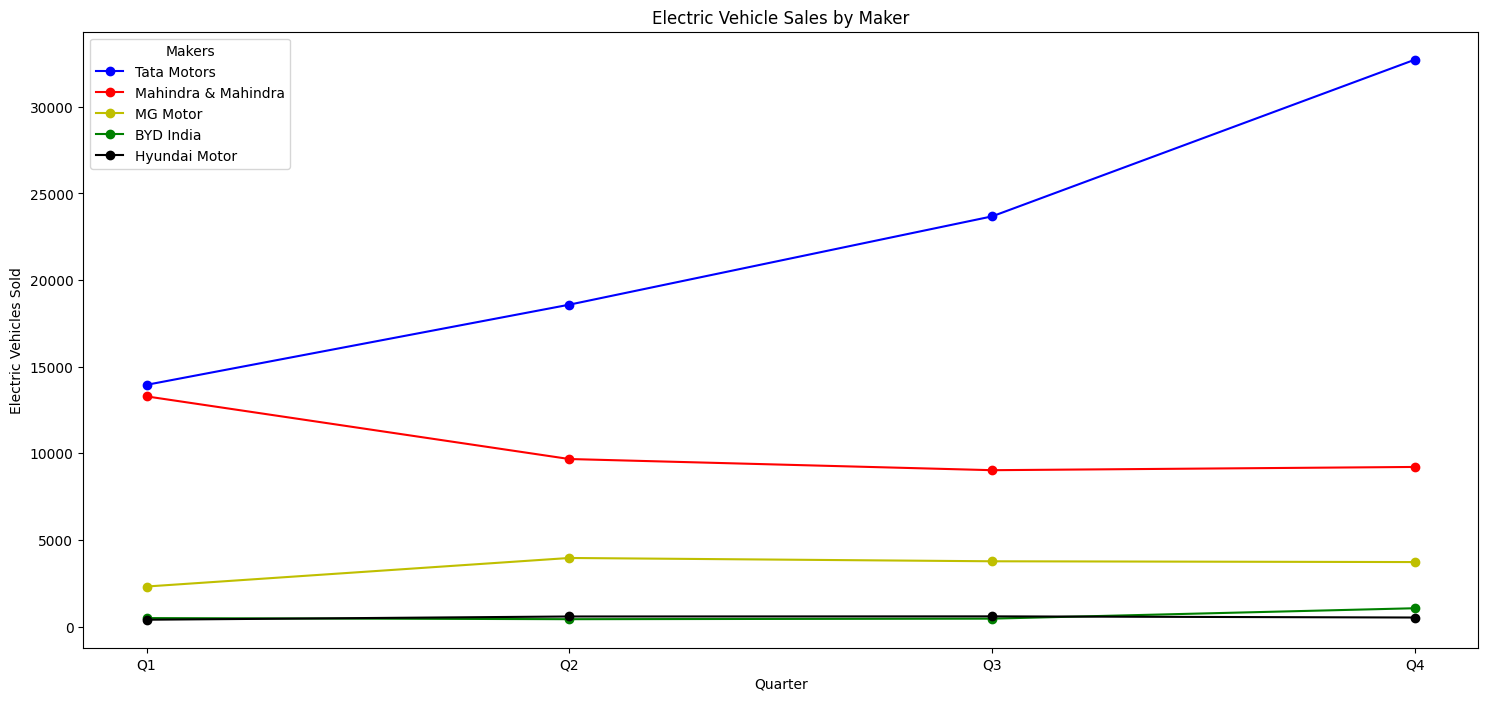

In [48]:
filtered=df_maker_sales[df_maker_sales['vehicle_category']=='4-Wheelers']
result4=filtered.groupby(['maker','quarter']).agg(electric_vehicles_sold=('electric_vehicles_sold',sum)).reset_index()
top_5_makers=filtered.groupby('maker').agg(electric_vehicles_sold=('electric_vehicles_sold',sum)).reset_index().sort_values('electric_vehicles_sold',ascending=False).head(5)

makers_to_filter = top_5_makers['maker']
# Filter result4 to include only rows where 'maker' is in top_5_makers
filtered_result4 = result4[result4['maker'].isin(makers_to_filter)].reset_index()
filtered_result4.drop(columns=['index'],inplace=True)

#for m,f in zip(makers_to_filter['maker'],formats):
   # plt.plot(filtered_result4['quarter'],filtered_result4['electric_vehicles_sold'],f,label=m)
#plt.show()  
#plt.legend()
plt.figure(figsize=(18,8),dpi=100)
formats=['b.-','r.-','y.-','g.-','k.-']
for m, f in zip(makers_to_filter, formats):  # Directly iterate over the list/Series
    # Filter the data for the current maker
    maker_data = filtered_result4[filtered_result4['maker'] == m]
    
    # Check if maker_data is empty (no data for this maker)
   # if maker_data.empty:
   #    print(f"Warning: No data found for maker {m}")
   #     continue

    # Plot the data for the current maker
    plt.plot(
        maker_data['quarter'],  # x-axis: quarters
        maker_data['electric_vehicles_sold'],  # y-axis= electric vehicles sold
        f,  # Line format
        label=m ,  # Label for the legend
        marker='o'
    )

# Add labels, legend, and title
plt.xlabel('Quarter')
plt.ylabel('Electric Vehicles Sold')
plt.legend(title='Makers')
plt.title('Electric Vehicle Sales by Maker')
plt.show()



## 5.How do the EV sales and penetration rates in Delhi compare to Karnataka for 2024?
## (OR between any two states)
#### (to compare between any two states ; assign the desired names in state1 & state2)

In [136]:
state1='Delhi'
state2='Karnataka'
filtered_e =df_state_sales[(df_state_sales['fiscal_year']==2024) & (df_state_sales['state'].isin([state1,state2]))]
filtered_e=filtered_e.groupby(['state','vehicle_category']).agg(electric_vehicles_sold=('electric_vehicles_sold',sum)
                                             ,total_vehicles_sold=('total_vehicles_sold',sum))
filtered_e['Penetration_rate']=filtered_e['electric_vehicles_sold']/filtered_e['total_vehicles_sold']
filtered_e

electric_vehicles_sold  total_vehicles_sold  \
state     vehicle_category                                                
Delhi     2-Wheelers                         38094               405218   
          4-Wheelers                          8630               201130   
Karnataka 2-Wheelers                        148111              1279767   
          4-Wheelers                         12878               302221   

                            Penetration_rate  
state     vehicle_category                    
Delhi     2-Wheelers                0.094009  
          4-Wheelers                0.042908  
Karnataka 2-Wheelers                0.115733  
          4-Wheelers                0.042611

## 6. List down the compounded annual growth rate (CAGR) in 4-wheeler units for the top 5 makers from 2022 to 2024.

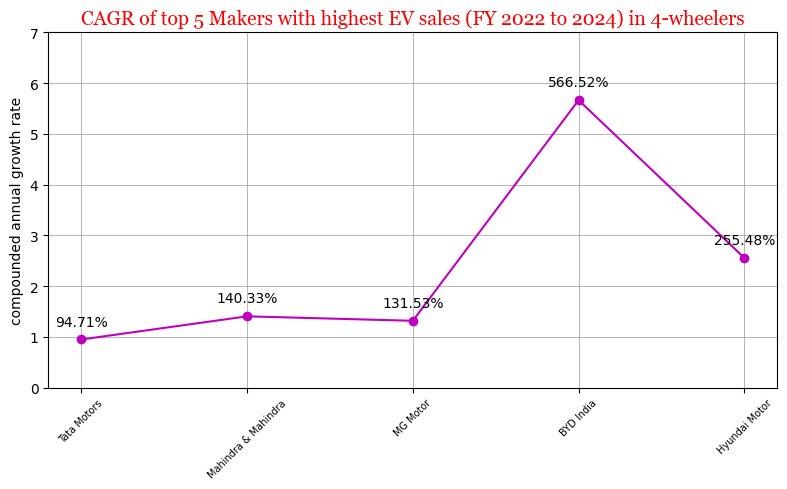

fiscal_year,2022,2023,2024,CAGR,Total_sales
maker,,,,,
Tata Motors,12708,28046,48181,0.947150,88935
Mahindra & Mahindra,4042,13805,23346,1.403301,41193
MG Motor,1647,3277,8829,1.315309,13753
BYD India,33,920,1466,5.665151,2419
Hyundai Motor,110,576,1390,2.554766,2076


In [52]:
filter_f=df_maker_sales[(df_maker_sales['vehicle_category']=='4-Wheelers') & (df_maker_sales['fiscal_year'].isin([2022,2023,2024]))]
filter_f=filter_f.groupby(['maker','fiscal_year']).agg(electric_vehicles_sold=('electric_vehicles_sold',sum)).reset_index()
filter_f=filter_f.pivot(columns='fiscal_year',index='maker',values='electric_vehicles_sold')
beginning_year=filter_f.columns.min()
ending_year=filter_f.columns.max()
number_of_years=ending_year-beginning_year
def calculate_cagr(start_value,end_value,periods,row=None):
    if start_value==0:
        if row is not None:
            # Use the corresponding value from the row for 2023
            start_value = row[2023]
        else:
            raise ValueError("start_value is 0, and no row data provided for default value.")
        
    return (end_value/start_value)**(1/periods) -1
filter_f['CAGR']= filter_f.apply(lambda row:calculate_cagr(row[2022],row[2024],periods=number_of_years,row=row),axis=1)

filter_f['Total_sales']=filter_f[2022]+filter_f[2023]+filter_f[2024]
top_5_Makers_CAGR=filter_f.nlargest(5,'Total_sales')

plt.figure(figsize=(8,5), dpi=100)
plt.plot(top_5_Makers_CAGR.index,top_5_Makers_CAGR['CAGR'],'o-m')

for i,val in enumerate(top_5_Makers_CAGR['CAGR']):
    plt.annotate(f'{val:.2%}',(top_5_Makers_CAGR.index[i],top_5_Makers_CAGR['CAGR'][i]),textcoords='offset points',xytext=(0,10),ha='center')
plt.title('CAGR of top 5 Makers with highest EV sales (FY 2022 to 2024) in 4-wheelers',font='Georgia',fontsize=14,color='red')
plt.ylabel('compounded annual growth rate')
plt.yticks(range(len(top_5_Makers_CAGR['CAGR']) +3))
plt.xticks(top_5_Makers_CAGR.index,rotation=45,fontsize=7)
plt.grid(color='grey', linestyle='-', linewidth=0.5, alpha=0.8)
 #plt.fill_between(top_5_Makers_CAGR.index,top_5_Makers_CAGR['CAGR'],color='yellow',alpha=0.4)
plt.tight_layout()
plt.savefig('top_makers_cagr.png',dpi=150) 
plt.show()
top_5_Makers_CAGR

## 7. List down the top 10 states that had the highest compounded annual growth rate (CAGR) from 2022 to 2024 in total vehicles sold.

In [54]:
filter_9=df_state_sales[(df_state_sales['fiscal_year'].isin([2022,2023,2024])) & (df_state_sales['vehicle_category'].isin(['2-Wheelers','4-Wheelers']))]
filter_9=filter_9.groupby(['state','fiscal_year']).agg({'total_vehicles_sold':sum}).reset_index()
filter_9=filter_9.pivot(columns='fiscal_year',index='state',values='total_vehicles_sold')
start_year=filter_9.columns.min()
last_year=filter_9.columns.max()
periods=last_year-start_year
def calculate_cagr(start_value,end_value,periods,row=None):#,start_value=None,end_value=None
    if start_value == 0:
        if row is not None:
            #checks if row parameter is passed(not None) while calling the func. , 
            #then only it will assign corresponding row[2023] value to start_value
            start_value=row[2023]
    return ((end_value/start_value)**(1/periods))-1
filter_9['CAGR']=filter_9.apply(lambda row:calculate_cagr(row[start_year],row[last_year],periods,row=row),axis=1)#,start_year=start_year,end_year=end_year
top_10_state_cagr=filter_9.nlargest(10,'CAGR')

#OR--top_10_state_cagr.sort_values(by='CAGR',ascending=False).head(10)
top_10_state_cagr=top_10_state_cagr[['CAGR']]
# Format CAGR values as percentages with 2 decimal places
top_10_state_cagr['CAGR'] = top_10_state_cagr['CAGR'].apply(lambda x: f"{x*100:.2f}%")
top_10_state_cagr


fiscal_year,CAGR
state,
Meghalaya,28.47%
Goa,27.41%
Karnataka,25.28%
Delhi,22.88%
Rajasthan,21.50%
Gujarat,20.55%
Assam,20.13%
Mizoram,18.77%
Arunachal Pradesh,18.30%


## 8. What are the peak and low season months for EV sales based on the data from 2022 to 2024

The peak month season is March with EV sales:138343
The low month season is May with EV sales:1499


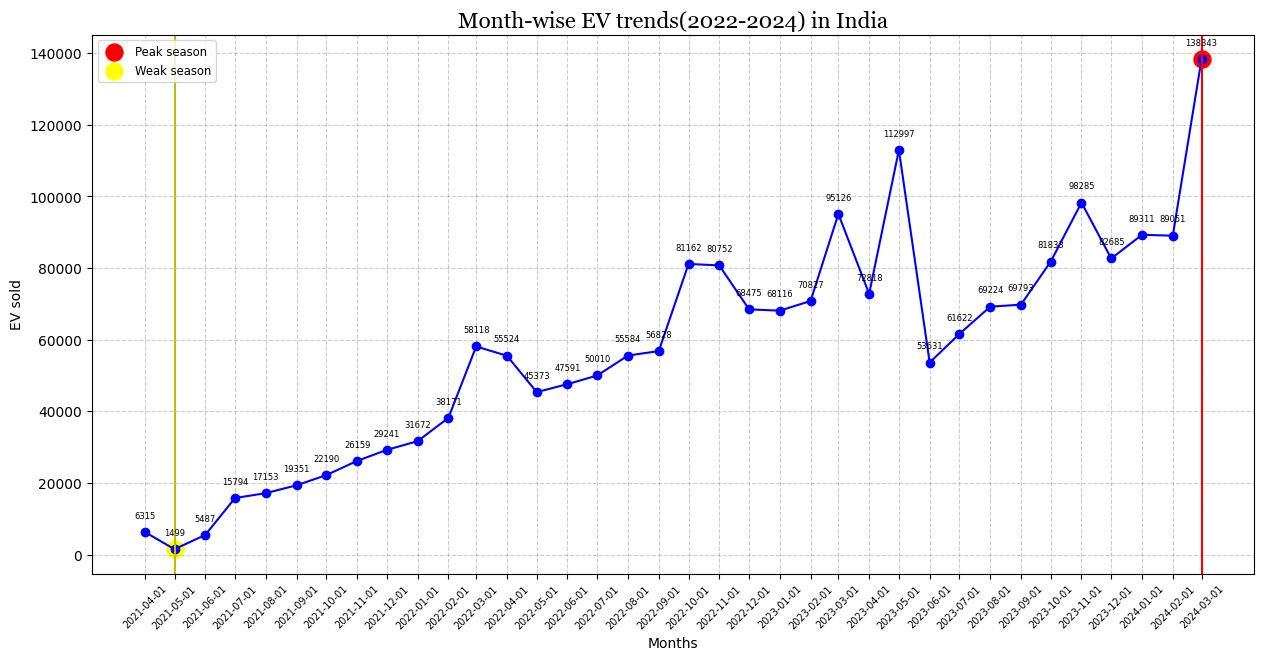

In [56]:
filter_8=df_state_sales[df_state_sales['fiscal_year'].isin([2022,2023,2024]) & df_state_sales['vehicle_category'].isin(['2-Wheelers','4-Wheelers'])]
filter_8['month']=filter_8['date'].dt.month_name()
# .dt.month will extract month number
filter_8['yyyy-m']=filter_8['date'].dt.to_period('M').dt.to_timestamp()

filter_8=filter_8.groupby(['fiscal_year','yyyy-m','month']).agg({'electric_vehicles_sold':sum}).reset_index()


peak_month=filter_8.iloc[filter_8['electric_vehicles_sold'].idxmax()]
low_month=filter_8.iloc[filter_8['electric_vehicles_sold'].idxmin()]

print(f"The peak month season is {peak_month['month']} with EV sales:{peak_month['electric_vehicles_sold']}")
print(f"The low month season is {low_month['month']} with EV sales:{low_month['electric_vehicles_sold']}")

plt.figure(figsize=(15,7),dpi=100)
plt.title('Month-wise EV trends(2022-2024) in India',font='Georgia',fontsize=16) 

plt.scatter(peak_month['yyyy-m'],peak_month['electric_vehicles_sold'],
        marker='o',s=150,c='red',alpha=1,
           label='Peak season')
plt.scatter(low_month['yyyy-m'],low_month['electric_vehicles_sold'],
        marker='o',s=150,c='yellow',alpha=1,
           label='Weak season')

plt.plot(filter_8['yyyy-m'],filter_8['electric_vehicles_sold'],color='blue',linestyle='-',marker='o')

for i,row in filter_8.iterrows():
    plt.annotate(f"{row['electric_vehicles_sold']}",
                 [row['yyyy-m'],row['electric_vehicles_sold']],
                 xytext=(0,10),
                 textcoords='offset points',
                 ha='center',
                fontsize=6                            
                 )

plt.xticks(filter_8['yyyy-m'],rotation=45,color='black',fontsize=7)
plt.xlabel('Months')
plt.ylabel('EV sold')
plt.grid(which='major',axis='both',linestyle='--',color='grey',alpha=0.4)
plt.axvline(peak_month['yyyy-m'],color='r',linestyle='-')
plt.axvline(low_month['yyyy-m'],color='y',linestyle='-')
plt.legend(loc='upper left',fontsize='small')
plt.show()


           

## 9. What is the projected number of EV sales (including 2-wheelers and 4-wheelers) for the top 10 states by penetration rate in 2030, based on the compounded annual growth rate (CAGR) from previous years?
### Projected Value=Current Value×(1+CAGR)^(Years)

state
Chhattisgarh    7.118219e+06
Delhi           1.054259e+06
Goa             2.419574e+06
Gujarat         8.646246e+06
Karnataka       8.383406e+06
Kerala          1.177940e+07
Maharashtra     1.335115e+07
Odisha          2.732814e+06
Rajasthan       2.404794e+06
Tamil Nadu      1.579547e+06
Name: Projected EV number in 2030, dtype: float64


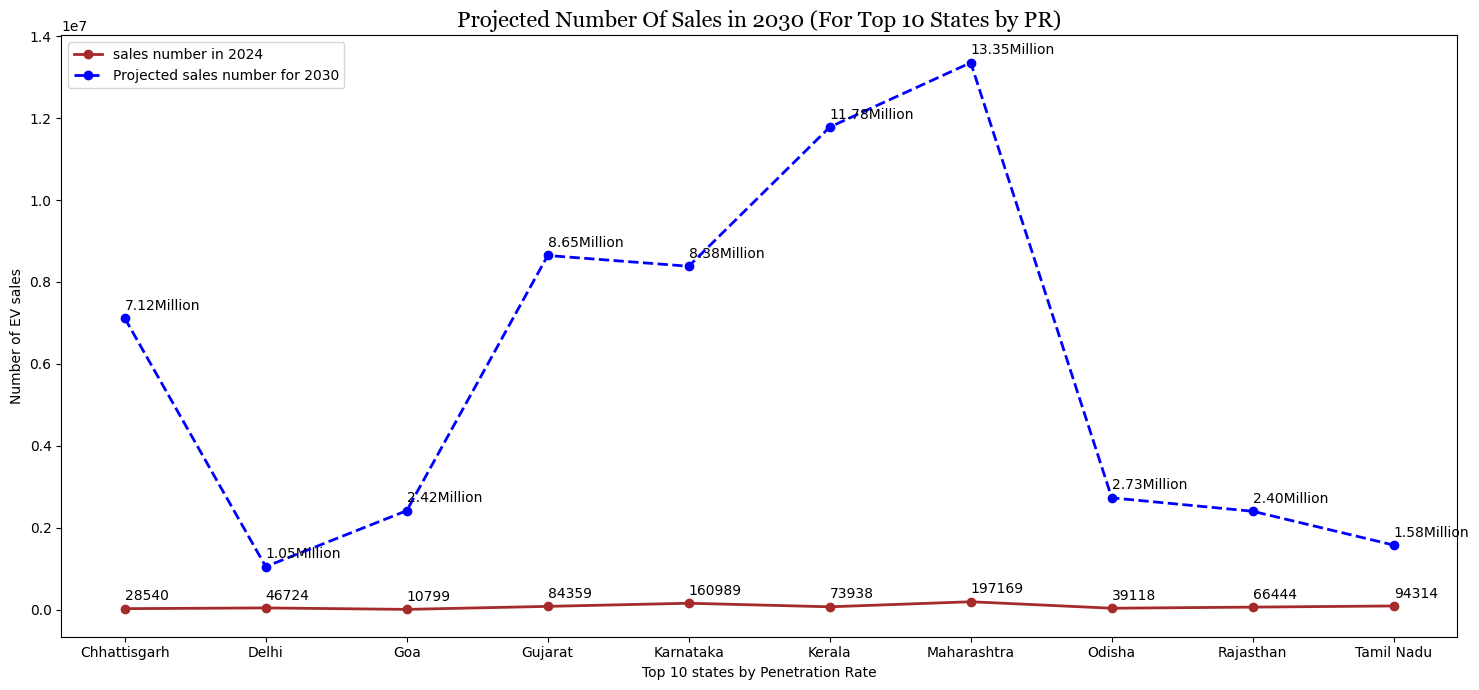

In [58]:
filter_9=df_state_sales[(df_state_sales['fiscal_year'].isin([2022,2023,2024])) & (df_state_sales['vehicle_category'].isin(['2-Wheelers','4-Wheelers']))]
filter_9=filter_9.groupby(['state','fiscal_year']).agg({'electric_vehicles_sold':sum}).reset_index()
filter_9=filter_9.pivot(columns='fiscal_year',index='state',values='electric_vehicles_sold')
start_year=filter_9.columns.min()
latest_year=filter_9.columns.max()
periods=last_year-start_year
def calculate_cagr(start_value,end_value,periods,row=None):#,start_value=None,end_value=None
    if start_value == 0:
        if row is not None:
            #checks if row parameter is passed(not None) while calling the func. , 
            #then only it will assign corresponding row[2023] value to start_value
            start_value=row[start_year+1]
    return ((end_value/start_value)**(1/periods))-1
filter_9['CAGR']=filter_9.apply(lambda row:calculate_cagr(row[start_year],row[latest_year],periods,row=row),axis=1)#,start_year=start_year,end_year=end_year

# filter_9 has all states with their previous cagr rate 
# top 10 states with highest PR
states_PR=df_state_sales.groupby('state').agg({'electric_vehicles_sold':sum,'total_vehicles_sold':sum})
states_PR['penetration rate']=states_PR['electric_vehicles_sold']/states_PR['total_vehicles_sold']*100
states_PR['penetration rate']=states_PR['penetration rate'].apply(lambda x: f'{x:.2}%')
top10_states_PR=states_PR.sort_values(by='penetration rate',ascending=False,axis=0).reset_index().head(10)
top10_states_PR.set_index('state',inplace=True)
filter_9=filter_9[filter_9.index.isin(top10_states_PR.index)]

#print(filter_9['state'].dtype)
#print(top10_states_PR['state'].dtype)

#merging two df by their index cols , so left_index=True, right_index=True;
filter_9=filter_9.merge(top10_states_PR[['penetration rate','electric_vehicles_sold']],left_index=True, right_index=True)
def calc_projected_EVsales(Current_value,CAGR,Years):
    if Current_value==0:
        raise ValueError('No data provided for 2024 electric vehicles sold')
    return Current_value*(1+CAGR)**Years
filter_9['Projected EV number in 2030']=filter_9.apply(lambda row:calc_projected_EVsales(row[last_year],row['CAGR'],Years=6),axis=1)

#to normalize the sales number , which was given in scientific notation( 7.118219e+06 )converted into standard fprmat
#filter_9['Projected EV number in 2030']=filter_9['Projected EV number in 2030'].apply(lambda x: f'{x/1e6:.2f}Million')
#print('Projected number of EV sold in 2030 in the present top 10 states') 
#filter_9['Projected EV number in 2030']=int(filter_9['Projected EV number in 2030'])
print(filter_9['Projected EV number in 2030'])

plt.figure(figsize=(15,7),dpi=100)
plt.title('Projected Number Of Sales in 2030 (For Top 10 States by PR)',font='Georgia',fontsize=16,color='black')

plt.plot(filter_9.index,filter_9[2024],color='brown',linestyle='-',dash_joinstyle='round',linewidth=2,marker='o',label='sales number in 2024')
for i,sales_no in enumerate(filter_9[2024]):
    plt.annotate(f"{sales_no}",xy=(filter_9.index[i],filter_9[2024][i]),xytext=(0,6),textcoords='offset points')

plt.plot(filter_9.index,filter_9['Projected EV number in 2030'],color='blue',linestyle='--',dash_joinstyle='round',linewidth=2,marker='o',label='Projected sales number for 2030')
for i,sales_no in enumerate(filter_9['Projected EV number in 2030']):
    plt.annotate(f"{sales_no/1e6 :.2f}Million",xy=(filter_9.index[i],filter_9['Projected EV number in 2030'][i]),xytext=(0,6),textcoords='offset points')

plt.xlabel('Top 10 states by Penetration Rate')
plt.ylabel('Number of EV sales')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 10. Estimate the revenue growth rate of 4-wheeler and 2-wheelers EVs in India for 2022 vs 2024 and 2023 vs 2024, assuming an average unit price. H
## average unit price for ,
1. 2-wheelers : 85,000
2. 4-wheelers : 15,00,000

In [60]:
df_state_sales
two_wheelers_revenue =df_state_sales[(df_state_sales['vehicle_category']=='2-Wheelers')&(df_state_sales['fiscal_year'].isin([2022,2023,2024]))].groupby('fiscal_year').agg(
    Number_of_EV_sold=('electric_vehicles_sold',sum)
).reset_index().set_index('fiscal_year')
#two_wheelers_revenue=two_wheelers_revenue.transpose()
four_wheelers_revenue =df_state_sales[(df_state_sales['vehicle_category']=='4-Wheelers')&(df_state_sales['fiscal_year'].isin([2022,2023,2024]))].groupby('fiscal_year').agg(
    Number_of_EV_sold=('electric_vehicles_sold',sum)
).reset_index().set_index('fiscal_year')

two_wheelers_revenue['2W-revenue']=two_wheelers_revenue['Number_of_EV_sold']* 85000 
two_wheelers_revenue['2W-revenue']=two_wheelers_revenue['2W-revenue'].apply(lambda x: f"${x:,.2f}")
four_wheelers_revenue['4W-revenue']=four_wheelers_revenue['Number_of_EV_sold']* 1500000
four_wheelers_revenue['4W-revenue']=four_wheelers_revenue['4W-revenue'].apply(lambda x: f"${x:,.2f}")

def revenue_growth_rate(start_year,end_year,df,price):
    revenue_start = df.loc[start_year,'Number_of_EV_sold'] * price if start_year in df.index else 0
    revenue_end = df.loc[end_year,'Number_of_EV_sold'] * price if start_year in df.index else 0
    if revenue_start==0:
       return float('inf')
    if revenue_end==0:
        return -100
    return round(((revenue_end - revenue_start)/revenue_start * 100),2)
price_2W =85000
price_4W = 1500000
growth_rate_2W_22vs24 = revenue_growth_rate(2022,2024,two_wheelers_revenue,price_2W)
growth_rate_2W_23vs24 = revenue_growth_rate(2023,2024,two_wheelers_revenue,price_2W)
growth_rate_4W_22vs24 = revenue_growth_rate(2022,2024,four_wheelers_revenue,price_4W)
growth_rate_4W_23vs24 = revenue_growth_rate(2023,2024,four_wheelers_revenue,price_4W)
print(two_wheelers_revenue)
print("\n")
print(four_wheelers_revenue)
print("\n")
print(f"Growth rate in EV revenue from FY 2022 to 2024 is {growth_rate_2W_22vs24}% in 2-wheelers.")
print(f"Growth rate in EV revenue from FY 2023 to 2024 is {growth_rate_2W_23vs24}% in 2-wheelers.")
print(f"Growth rate in EV revenue from FY 2022 to 2024 is {growth_rate_4W_22vs24}% in 4-wheelers.")
print(f"Growth rate in EV revenue from FY 2023 to 2024 is {growth_rate_4W_23vs24}% in 4-wheelers.")



             Number_of_EV_sold          2W-revenue
fiscal_year                                       
2022                    252573  $21,468,705,000.00
2023                    727903  $61,871,755,000.00
2024                    932692  $79,278,820,000.00


             Number_of_EV_sold           4W-revenue
fiscal_year                                        
2022                     18577   $27,865,500,000.00
2023                     47465   $71,197,500,000.00
2024                     86901  $130,351,500,000.00


Growth rate in EV revenue from FY 2022 to 2024 is 269.28% in 2-wheelers.
Growth rate in EV revenue from FY 2023 to 2024 is 28.13% in 2-wheelers.
Growth rate in EV revenue from FY 2022 to 2024 is 367.79% in 4-wheelers.
Growth rate in EV revenue from FY 2023 to 2024 is 83.08% in 4-wheelers.


# <center> Extracting insights from Data </center>

1. What are the primary reasons for customers choosing 4-wheeler EVs in 2023 and 2024 (cost savings, environmental concerns, government incentives)?
2. How do government incentives and subsidies impact the adoption rates of 2-wheelers and 4-wheelers? Which states in India provided most subsidies?
3. How does the availability of charging stations infrastructure correlate with the EV sales and penetration rates in the top 5 states?
4. Who should be the brand ambassador if AtliQ Motors launches their EV/Hybrid vehicles in India and why?
5. Which state of India is ideal to start the manufacturing unit? (Based on subsidies provided, ease of doing business, stability in governance etc.)
6. Your top 3 recommendations for AtliQ Motors.


- Electric vehicle sales will reach one in five cars sold around the world, according to International Energy Agency projections.
- The transition to electric vehicles is an important part of the shift to clean energy. Road transport accounts for around one-sixth of all global emissions from energy, according to the International Energy Agency. Widespread EV adoption could significantly address climate change.
- 

